In [1]:
## SECTION 1 - IMPORTS ##

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [2]:
## SECTION 2 - LOAD DATA ##

# Load datasets
well1 = pd.read_csv("1_2021002_.csv")
well4 = pd.read_csv("4_20211022_.csv")
well7 = pd.read_csv("7_2021022_.csv")

# Fix column issues
well4 = well4.rename(columns={"litholody": "lithology"})
well7 = well7.rename(columns={"litholody": "lithology"})

# Add well labels
well1["well"] = "well1"
well4["well"] = "well4"
well7["well"] = "well7"

# Combine
all_data = pd.concat([well1, well4, well7], axis=0)

In [3]:
## SECTION 3 - DATA CLEANING ##

# Standardize column names
all_data = all_data.rename(columns={"depth(m)": "depth"})
all_data = all_data.loc[:, ~all_data.columns.duplicated()]

# Keep relevant columns
columns = ["depth", "SP", "GR", "LLD", "LLS", "DEN", "AC", "lithology", "well"]
all_data = all_data[columns]

# Remove rows without target
all_data = all_data.dropna(subset=["lithology"])

# Fill missing values
features = ["depth", "SP", "GR", "LLD", "LLS", "DEN", "AC"]
all_data[features] = all_data[features].fillna(all_data[features].mean())

In [4]:
## SECTION 4 - DATA OVERVIEW ##

all_data["well"].value_counts()
all_data["lithology"].value_counts()

shale    19701
sand      6903
Name: lithology, dtype: int64

In [5]:
## SECTION 5 - TRAIN/TEST SPLIT BY WELL

train_data = all_data[all_data["well"] != "well7"]
test_data = all_data[all_data["well"] == "well7"]

X_train = train_data[features]
X_test = test_data[features]

le = LabelEncoder()
y_train = le.fit_transform(train_data["lithology"])
y_test = le.transform(test_data["lithology"])

In [7]:
## SECTION 6 - TRAIN MODEL  ##

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [8]:
## SECTION 7 - EVALUATION  ##

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9116570033567287


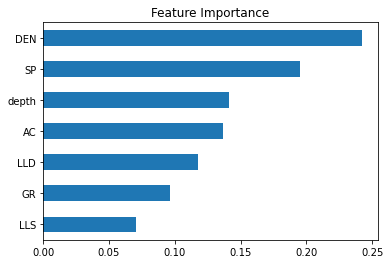

In [9]:
## SECTION 8 - FEATURE IMPORTANCE ##

importance = pd.Series(model.feature_importances_, index=features)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()